<a href="https://colab.research.google.com/github/tommasobby/Streamlit/blob/main/Movie_eda_TommasoQuintiliani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [4]:
df = pd.read_csv('movies.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [6]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
movieId    0
title      0
genres     0
dtype: int64


In [7]:
df['Year'] = df['title'].str.extract(r'\((\d{4})\)$')
df['Title'] = df['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True).str.strip()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df = df[['movieId', 'Title', 'Year', 'genres']]
print(f'Righe con Year mancante: {df["Year"].isnull().sum()}')
df.head(10)

Righe con Year mancante: 24


,movieId,Title,Year,genres
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,1995.0,Adventure|Children|Fantasy
2,3,Grumpier Old Men,1995.0,Comedy|Romance
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,5,Father of the Bride Part II,1995.0,Comedy
5,6,Heat,1995.0,Action|Crime|Thriller
6,7,Sabrina,1995.0,Comedy|Romance
7,8,Tom and Huck,1995.0,Adventure|Children
8,9,Sudden Death,1995.0,Action
9,10,GoldenEye,1995.0,Action|Adventure|Thriller


In [8]:
genre_series = df['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts().drop('(no genres listed)', errors='ignore')

print('Generi unici:', genre_counts.shape[0])
print(genre_counts)

Generi unici: 19
genres
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87
Name: count, dtype: int64


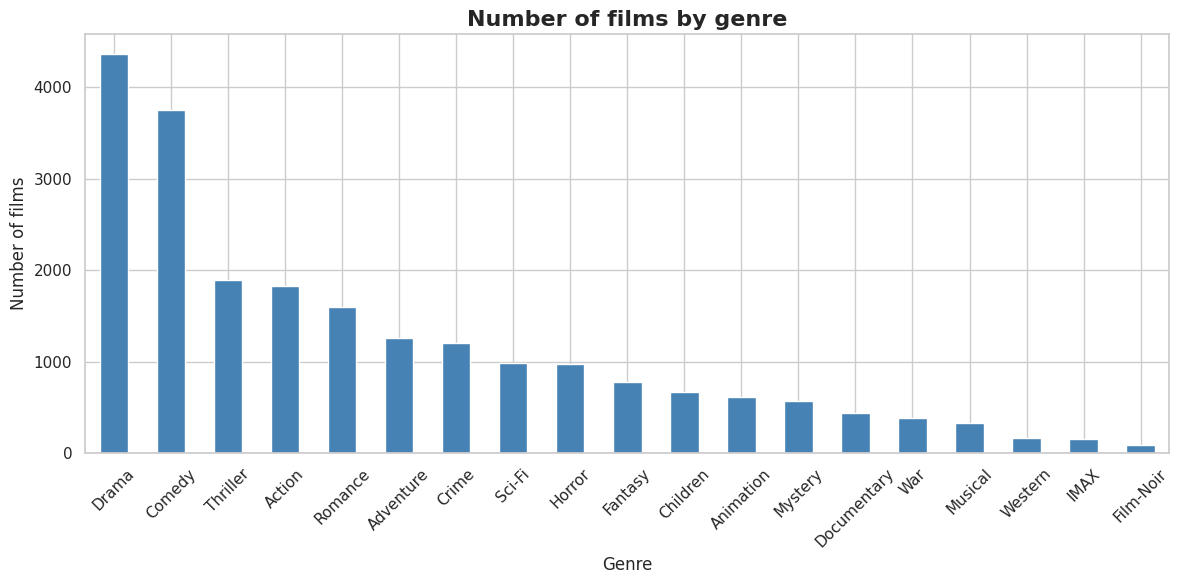

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of films by genre', fontsize=16, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of films')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

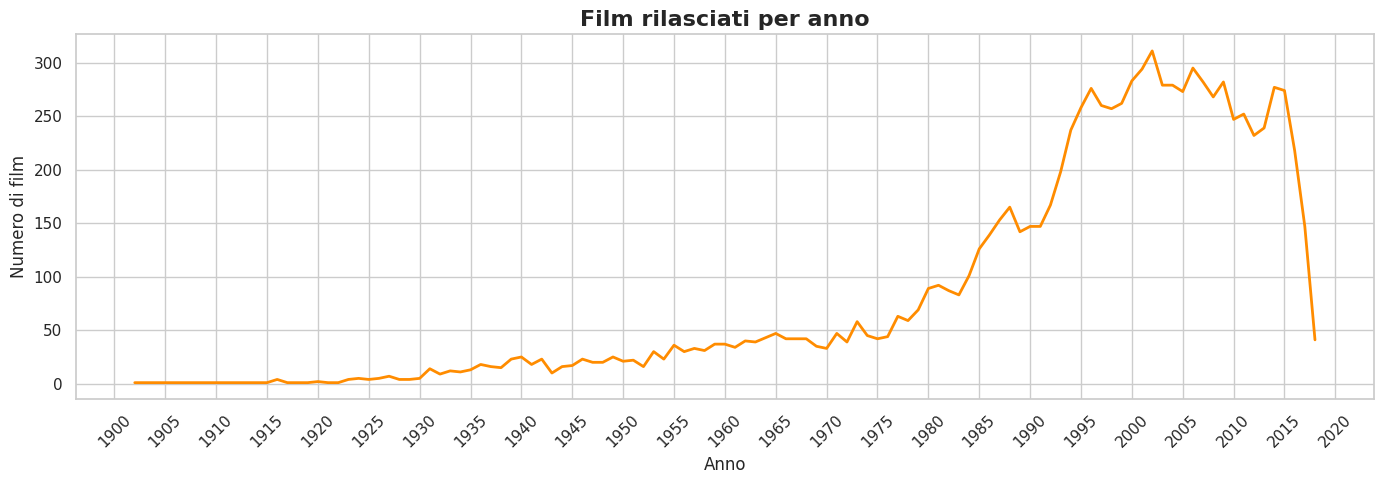

In [11]:
movies_per_year = df.dropna(subset=['Year']).groupby('Year').size()

fig, ax = plt.subplots(figsize=(14, 5))
movies_per_year.plot(ax=ax, color='darkorange', linewidth=2)
ax.set_title('Film rilasciati per anno', fontsize=16, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Numero di film')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Media generi per film: 2.26
genre_count
0       34
1     2817
2     3218
3     2338
4      987
5      271
6       63
7       12
8        1
10       1
Name: count, dtype: int64


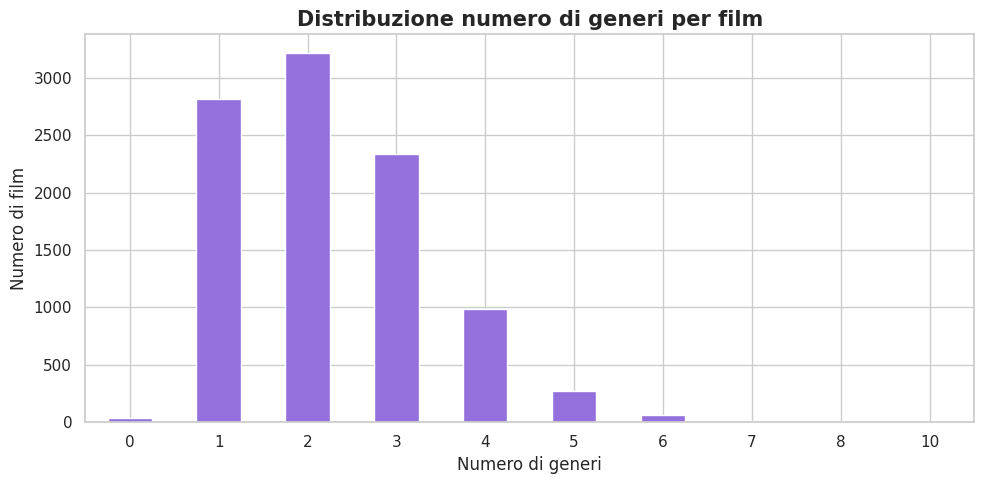

In [12]:
df['genre_count'] = df['genres'].apply(lambda x: len(x.split('|')) if x != '(no genres listed)' else 0)

print('Media generi per film:', round(df['genre_count'].mean(), 2))
print(df['genre_count'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 5))
df['genre_count'].value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Distribuzione numero di generi per film', fontsize=15, fontweight='bold')
ax.set_xlabel('Numero di generi')
ax.set_ylabel('Numero di film')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [13]:
df_clean = df.drop(columns=['genre_count'])
df_clean.to_csv('movies_clean.csv', index=False)
print('✅ File salvato come movies_clean.csv')
df_clean.head()

✅ File salvato come movies_clean.csv


,movieId,Title,Year,genres
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,1995.0,Adventure|Children|Fantasy
2,3,Grumpier Old Men,1995.0,Comedy|Romance
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,5,Father of the Bride Part II,1995.0,Comedy
